In [36]:
rm(list = ls())

In [39]:
ls()

[1] "add_df"            "ag_cn_com"         "cat_mark_mc"      
 [4] "cfupn"             "cond1"             "cond10"           
 [7] "cond11"            "cond12"            "cond2"            
[10] "cond3"             "cond7"             "cond8"            
[13] "cond9"             "cpn"               "day_mat"          
[16] "db_path"           "fp_marks"          "i"                
[19] "K"                 "legc"              "mat"              
[22] "mature_inds"       "max_day"           "mc"               
[25] "mc_ag"             "mc_ag_c"           "mc_ag_cn"         
[28] "mc_ag_n"           "mcf"               "mcmd"             
[31] "mcs_by_st"         "mct"               "mg_bon"           
[34] "mg_bon_out"        "nc"                "net"              
[37] "neuron_st"         "nm"                "save_pheatmap_png"
[40] "SEED"              "st"                "st_mark_mc"       
[43] "st_mc_t"           "tbl"               "wd"               
[46] "x"

In [38]:
library('metacell')
library(dplyr)

wd = '/home/feshap/raid/proj/mmcortex'
setwd(wd)
db_path = file.path(wd, 'scdb')
scdb_init(db_path, force_reinit = T)

SEED = 1337
K = 16
set.seed(SEED)
scfigs_init("figs/")

nm = 'pl_cort'

tgconfig::set_param('mcp_heatmap_height', 2500, 'metacell')
tgconfig::set_param('mcp_heatmap_width', 4500, 'metacell')

save_pheatmap_png <- function(x, filename, width=2500, height=2500, res = 150) {
  png(filename, width = width, height = height, res = res)
  grid::grid.newpage()
  grid::grid.draw(x$gtable)
  dev.off()
}

mc = scdb_mc(nm)
mat = scdb_mat(nm)

mg_bon = read.delim('./BonevCollab//marker_genes.tsv', sep='\t') %>% 
            apply(1, function(x) stringr::str_split(x, pattern = ' ')) %>%
            purrr::map(1) %>% purrr::map(function(x) c(x[[1]], stringr::str_split(x[[length(x)]], ',')))

mg_bon = unique(data.frame(cbind(purrr::map(mg_bon, 1), purrr::map(mg_bon, 2))))
colnames(mg_bon) = c('st', 'marks')
mg_bon = mg_bon[mg_bon$st %in% c('NSC', 'IPC', 'CthPN', 'SCPN', 'Stellate_L4', 'CPN_L2-3', 'CPN_L5_6', 'Oligodendrocytes', 'Astrocytes'),]

mg_bon$marks[mg_bon$st == 'Astrocytes'] = list(unlist(c(mg_bon$marks[mg_bon$st == 'Astrocytes'], 'Fabp7', 'Slc1a3', 'Cst3')))
mg_bon$marks[mg_bon$st == 'Oligodendrocytes'] = list(unlist(c(mg_bon$marks[mg_bon$st == 'Oligodendrocytes'])))
mg_bon$marks[mg_bon$st == 'SCPN'] = list(unlist(c(mg_bon$marks[mg_bon$st == 'SCPN'])))
mg_bon$marks[mg_bon$st == 'CthPN'] = list(unlist(c(mg_bon$marks[mg_bon$st == 'CthPN'], 'Foxp2', 'Hs3st4', 'Prickle1')))
mg_bon$marks[mg_bon$st == 'CPN_L2-3'] = list(unlist(c(mg_bon$marks[mg_bon$st == 'CPN_L2-3'], c('Eif1b', 'Gpm6a'))))
mg_bon$marks[mg_bon$st == 'CPN_L5_6'] = list(unlist(c(mg_bon$marks[mg_bon$st == 'CPN_L5_6'], 'Gucy1a1', 'Gucy1b1', 'Syt4')))

x = unlist(mg_bon$marks[mg_bon$st == 'CthPN'])
x = list(x[x != 'Sox5'])
mg_bon$marks[mg_bon$st == 'CthPN'] = x

                                         
add_df = data.frame(rbind(
    list(st = 'Mature', marks = c('Mef2c', 'Mapt', 'Stmn2')),
    list(st = 'Immature', marks = c('Neurod1', 'Sstr2', 'Rnd2')),
    list(st = 'Cycling', marks = c('Pcna', 'Top2a', 'Mki67', 'Ube2c'))
))

mg_bon = rbind(mg_bon, add_df)
mg_bon_out = as.data.frame(apply(mg_bon, 2, function(x) sapply(x, function(y) paste0(y, collapse = ', '))))
readr::write_csv(mg_bon_out, file = "./data/pl_mg_bon.csv")

legc <- log2(1e-5 + mc@e_gc)
fp_marks <- mc@mc_fp[sort(unique(unlist(mg_bon$marks))),]

st_mark_mc = sapply(mg_bon$marks, function(x) apply(fp_marks[as.character(x),], 2, mean))
st_mark_mc = data.frame(st_mark_mc)
colnames(st_mark_mc) = unlist(mg_bon$st)
st_mark_mc$CPN = apply(st_mark_mc[,c('CPN_L2-3', 'CPN_L5_6')], 1, max)
st_mark_mc$CfuPN = apply(st_mark_mc[,c('SCPN', 'CthPN')], 1, max)
cat_mark_mc = st_mark_mc[,c('CPN', 'CfuPN', 'Mature', 'Immature', 'Cycling')]
cat_mark_mc$cpn_cfu_rat = log2(cat_mark_mc$CPN/cat_mark_mc$CfuPN)
cat_mark_mc$mat_imm_rat = log2(cat_mark_mc$Mature/cat_mark_mc$Immature)
st_mark_mc[,c('CPN', 'CfuPN', 'Mature', 'Immature', 'Cycling')] = c()

day_mat = matrix(0, nrow=length(unique(mc@mc)), ncol = length(unique(mat@cell_metadata[names(mc@mc),'day'])))
colnames(day_mat) = sort(unique(mat@cell_metadata[names(mc@mc),'day']))
rownames(day_mat) = 1:nrow(day_mat)
for (i in 1:nrow(day_mat)) {
    tbl = table(mat@cell_metadata[names(mc@mc)[mc@mc == i], 'day'])
    day_mat[i,names(tbl)] = tbl
}


max_day = apply(day_mat, 1, which.max)

cond1 = apply(st_mark_mc, 1, max) > 2                                   ## filter for high st specificity
cond2 = cat_mark_mc$mat_imm_rat > 2 & 
                    legc['Mef2c',] >= -10.5 & 
                    legc['Mapt',] >= -10.5 
                    ## filter for mature mcs
cond3 = colnames(st_mark_mc)[apply(st_mark_mc, 1, which.max)] %in% 
                c('NSC', 'IPC', 'Astrocytes', 'Oligodendrocytes')       ## Check neural or glial
cond7 = cat_mark_mc$cpn_cfu_rat >= log2(2)                              ## filter for CPN-tending
cond8 = cat_mark_mc$cpn_cfu_rat <= -log2(2)                             ## filter for CfuPN-tending
cond9 = colnames(st_mark_mc)[apply(st_mark_mc, 1, which.max)] == 'NSC'
cond10 = colnames(st_mark_mc)[apply(st_mark_mc, 1, which.max)] == 'IPC'
cond11 = cat_mark_mc$Cycling >= 2
cond12 = cond2 & (cond7 | cond8)

st = ifelse(cond1 & cond3, colnames(st_mark_mc)[apply(st_mark_mc, 1, which.max)], NA)

st[is.na(st) & cond9] = 'NSC'
st[cond10 & cond11] = 'IPC_cyc'
st[st == 'Astrocytes' & st_mark_mc$Astrocytes < 15] <- 'NSC'


mature_inds = as.numeric(which((cond1 & cond2) & is.na(st)))
st[mature_inds] = colnames(st_mark_mc)[apply(st_mark_mc[mature_inds,], 1, which.max)]

neuron_st = c('CPN_L2-3','CPN_L5_6','SCPN','CthPN')
cpn = c('CPN_L5_6', 'CPN_L2-3')
cfupn = c('CthPN', 'SCPN')

devtools::load_all('~/src//metacell.flow')

scdb_flow_init()

mat = scdb_mat(nm)

mct = scdb_mctnetwork(nm)
mcf = scdb_mctnetflow(nm)

net = mct@network
net$flow = mcf@edge_flows

net = net[net$flow > 0,]
net = net[net$type1 == 'norm_f',]
net = net[net$type2 != 'sink',]

mcmd = vroom::vroom('./BonevCollab//mcmd_pl.tsv')

mc_ag = table(mc@mc,mat@cell_metadata[names(mc@mc),"day"])
mc_ag_n = mc_ag/rowSums(mc_ag)
mc_ag_c = t(t(mc_ag)/colSums(mc_ag))
mc_ag_cn = mc_ag_c/rowSums(mc_ag_c)

ag_cn_com = apply(mc_ag_cn, 1, function(x) sum(x*(13:18))/sum(x))

nc = ncol(mc_ag_cn)

mcs_by_st = lapply(unique(st), function(u) setNames(mcmd$mean_day[which(st == u)], which(st == u)))
names(mcs_by_st) = unique(st)
# mcs_by_st

st_mc_t = lapply(mcs_by_st[neuron_st[neuron_st %in% names(mcs_by_st)]], function(x) round(x)-12)
names(st_mc_t) = names(mcs_by_st[neuron_st[neuron_st %in% names(mcs_by_st)]])
# st_mc_t

# mcs_by_st

                 

initializing scdb to /home/feshap/raid/proj/mmcortex/scdb

ℹ Loading metacell.flow

Rows: 454 Columns: 11
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): st, color
dbl (9): mc, E13, E14, E15, E16, E17, E18, mean_day, time_bin

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [40]:
mcmd_new <- readr::read_tsv('./BonevCollab/mcmd_pl_cort.tsv')

Rows: 454 Columns: 11
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): st, color
dbl (9): mc, E13, E14, E15, E16, E17, E18, mean_day, time_bin

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [41]:
fp_st <- t(tgs_matrix_tapply(mc@mc_fp, mcmd_new$st, mean))

In [8]:
gene_modules <- setNames(lapply(1:ncol(fp_st), function(i) names(head(fp_st[order(fp_st[,i], decreasing = T),i], 10))), colnames(fp_st))

In [56]:
gene_modules <- gene_modules[names(gene_modules) != 'IPC_late']

In [57]:
save(gene_modules, file = './data/gene_modules_mcmd_pl_cort.Rda')

In [42]:
load('./data/gene_modules_mcmd_pl_cort.Rda')

In [43]:
gene_modules

$Astrocytes
 [1] "Fabp7"  "Dbi"    "Mt3"    "Aldoc"  "Ptprz1" "Apoe"   "Vim"    "Hes5"  
 [9] "Ddah1"  "Slc1a3"

$`CPN_L2-3`
 [1] "Stmn2"   "Mef2c"   "Satb2"   "Mapt"    "Ly6h"    "Gpm6a"   "Ptn"    
 [8] "Dab1"    "Runx1t1" "Ptprz1" 

$CPN_L5_6
 [1] "Mef2c"   "Stmn2"   "Mapt"    "Syt4"    "Runx1t1" "Ly6h"    "Satb2"  
 [8] "Ncam1"   "Gap43"   "Gucy1a1"

$CthPN
 [1] "Meg3"   "Stmn2"  "Mef2c"  "Ina"    "Mapt"   "Hs3st4" "Tubb2a" "Islr2" 
 [9] "Sox5"   "Bcl11b"

$iCfuPN
 [1] "Bcl11b"  "Runx1t1" "Stmn2"   "Sox5"    "Islr2"   "Ina"     "Cntn2"  
 [8] "Gap43"   "Csrp2"   "Ier5"   

$iCPN_early
 [1] "Pou3f2" "Unc5d"  "Pcp4"   "Sema3c" "Sstr2"  "Zbtb20" "Rnd2"   "Frmd4a"
 [9] "Nrp1"   "Meis2" 

$iCPN_late
 [1] "Stmn2"   "Nrp1"    "Satb2"   "Cntn2"   "Mapt"    "Frmd4a"  "Gria2"  
 [8] "Ly6h"    "Runx1t1" "Mef2c"  

$`iCPN/CfuPN`
 [1] "Rnd2"    "Bcl11b"  "Sema6d"  "Gadd45g" "Sstr2"   "Gm26917" "Cntn2"  
 [8] "Vat1"    "Neurod1" "Epha5"  

$IPC
 [1] "Hes5"    "Neurog2" "Eomes"   "Gadd45g" "Dbi"     "Vim"     "Btg2"   
 [8] "Ccnd2"   "Igsf8"   "Mfng"   

$IPC_cyc
 [1] "Hmgb2"     "Hist1h2ap" "Ube2c"     "Top2a"     "Pclaf"     "Hist1h1b" 
 [7] "Cks2"      "Cenpf"     "Cenpa"     "Gadd45g"  

$NSC
 [1] "Fabp7"     "Dbi"       "Vim"       "Hmgb2"     "Hist1h2ap" "Hes5"     
 [7] "Id4"       "Mt3"       "Ddah1"     "Aldoc"    

$Oligodendrocytes
 [1] "Olig1"  "Fabp7"  "Olig2"  "Hes5"   "Ptprz1" "Pdgfra" "Sox9"   "Qk"    
 [9] "Ncald"  "Egr1"  

$SCPN
 [1] "Meg3"   "Stmn2"  "Ina"    "Bcl11b" "Mapt"   "Mef2c"  "Sox5"   "Ly6h"  
 [9] "Islr2"  "Tubb2a"

In [44]:
mc_module_score <- t(sapply(gene_modules, function(mi) colSums(mc@mc_fp[mi,])))

In [45]:
table(st)

st
      Astrocytes         CPN_L2-3         CPN_L5_6            CthPN 
               9                6               15               13 
             IPC          IPC_cyc              NSC Oligodendrocytes 
              72               19               79                2 
            SCPN 
               9 

In [46]:
length(which(is.na(st)))

[1] 230

In [47]:
st[which(is.na(st))] <- rownames(mc_module_score)[apply(mc_module_score[,which(is.na(st))], 2, which.max)]

In [48]:
cpn

[1] "CPN_L5_6" "CPN_L2-3"

In [49]:
tot_outflow_thresh <- 0.25
st_bad <- c('CPN_L5_6', 'CPN_L2-3', 'iCPN_late')
mcs_that_flow_to_CPN <- which(colSums(do.call('rbind', lapply(mcf@mc_forward, function(x) rowSums(x[,st %in% st_bad])))) >= tot_outflow_thresh)

st_bad <- c('SCPN', 'CfuPN')
mcs_that_flow_to_CfuPN <- which(colSums(do.call('rbind', lapply(mcf@mc_forward, function(x) rowSums(x[,st %in% st_bad])))) >= tot_outflow_thresh)

icpn_cfupn_inds <- intersect(mcs_that_flow_to_CPN, mcs_that_flow_to_CfuPN)
icpn_late_inds <- setdiff(mcs_that_flow_to_CPN, union(which(mcmd$st %in% cpn), icpn_cfupn_inds))
bad_icfupn_inds <- which(st == 'iCfuPN')[which(st == 'iCfuPN') %in% union(icpn_cfupn_inds, icpn_late_inds)]


In [50]:
options(repr.plot.width = 6)
options(repr.plot.height = 6)

In [52]:
lapply(mcf@mc_forward, function(x) apply(x[which(st == 'SCPN'),], 1, function(y) st[which(y != 0)]))

[[1]]
[[1]]$`377`
    395     402     404 
"CthPN" "CthPN"  "SCPN" 

[[1]]$`378`
    389     395     396 
"CthPN" "CthPN" "CthPN" 

[[1]]$`380`
    409     410 
"CthPN"  "SCPN" 

[[1]]$`383`
named character(0)

[[1]]$`384`
named character(0)

[[1]]$`385`
named character(0)

[[1]]$`386`
named character(0)

[[1]]$`387`
named character(0)

[[1]]$`388`
named character(0)

[[1]]$`393`
named character(0)

[[1]]$`397`
named character(0)

[[1]]$`401`
named character(0)

[[1]]$`403`
named character(0)

[[1]]$`404`
named character(0)

[[1]]$`406`
named character(0)

[[1]]$`408`
    389 
"CthPN" 

[[1]]$`410`
    395 
"CthPN" 

[[1]]$`412`
named character(0)

[[1]]$`414`
named character(0)

[[1]]$`415`
named character(0)

[[1]]$`416`
named character(0)

[[1]]$`417`
named character(0)


[[2]]
[[2]]$`377`
    398     402 
"CthPN" "CthPN" 

[[2]]$`378`
    389     394     402 
"CthPN" "CthPN" "CthPN" 

[[2]]$`380`
    395     405 
"CthPN" "CthPN" 

[[2]]$`383`
named character(0)

[[2]]$`384`
named character(0)

[[2]]$`385`
named character(0)

[[2]]$`386`
named character(0)

[[2]]$`387`
named character(0)

[[2]]$`388`
    396 
"CthPN" 

[[2]]$`393`
named character(0)

[[2]]$`397`
named character(0)

[[2]]$`401`
    402 
"CthPN" 

[[2]]$`403`
named character(0)

[[2]]$`404`
    396 
"CthPN" 

[[2]]$`406`
    390     396 
"CthPN" "CthPN" 

[[2]]$`408`
    389     392     399 
"CthPN" "CthPN" "CthPN" 

[[2]]$`410`
    395     399 
"CthPN" "CthPN" 

[[2]]$`412`
    413 
"CthPN" 

[[2]]$`414`
named character(0)

[[2]]$`415`
named character(0)

[[2]]$`416`
named character(0)

[[2]]$`417`
named character(0)


[[3]]
[[3]]$`377`
    407 
"CthPN" 

[[3]]$`378`
    395 
"CthPN" 

[[3]]$`380`
named character(0)

[[3]]$`383`
    399 
"CthPN" 

[[3]]$`384`
   384    393    397    416    417 
"SCPN" "SCPN" "SCPN" "SCPN" "SCPN" 

[[3]]$`385`
   397 
"SCPN" 

[[3]]$`386`
   403 
"SCPN" 

[[3]]$`387`
   397 
"SCPN" 

[[3]]$`388`
    396     399 
"CthPN" "CthPN" 

[[3]]$`393`
named character(0)

[[3]]$`397`
    399 
"CthPN" 

[[3]]$`401`
    398     403     404     405 
"CthPN"  "SCPN"  "SCPN" "CthPN" 

[[3]]$`403`
    399 
"CthPN" 

[[3]]$`404`
    402 
"CthPN" 

[[3]]$`406`
    398 
"CthPN" 

[[3]]$`408`
    404     407 
 "SCPN" "CthPN" 

[[3]]$`410`
    395     404     410 
"CthPN"  "SCPN"  "SCPN" 

[[3]]$`412`
    413 
"CthPN" 

[[3]]$`414`
   414 
"SCPN" 

[[3]]$`415`
   393 
"SCPN" 

[[3]]$`416`
named character(0)

[[3]]$`417`
   393 
"SCPN" 


[[4]]
[[4]]$`377`
named character(0)

[[4]]$`378`
named character(0)

[[4]]$`380`
named character(0)

[[4]]$`383`
       416        446 
    "SCPN" "CPN_L5_6" 

[[4]]$`384`
       453 
"CPN_L5_6" 

[[4]]$`385`
       432 
"CPN_L2-3" 

[[4]]$`386`
       432 
"CPN_L2-3" 

[[4]]$`387`
       446        452        453        454 
"CPN_L5_6" "CPN_L5_6" "CPN_L5_6" "CPN_L5_6" 

[[4]]$`388`
       443 
"CPN_L5_6" 

[[4]]$`393`
       454 
"CPN_L5_6" 

[[4]]$`397`
   387    415    417 
"SCPN" "SCPN" "SCPN" 

[[4]]$`401`
       432 
"CPN_L2-3" 

[[4]]$`403`
   393    415    416 
"SCPN" "SCPN" "SCPN" 

[[4]]$`404`
   386    417 
"SCPN" "SCPN" 

[[4]]$`406`
       416        443 
    "SCPN" "CPN_L5_6" 

[[4]]$`408`
named character(0)

[[4]]$`410`
   383    388    404    406    410 
"SCPN" "SCPN" "SCPN" "SCPN" "SCPN" 

[[4]]$`412`
       411        412 
"CPN_L2-3"     "SCPN" 

[[4]]$`414`
   414 
"SCPN" 

[[4]]$`415`
       449 
"CPN_L5_6" 

[[4]]$`416`
       447 
"CPN_L5_6" 

[[4]]$`417`
       453 
"CPN_L5_6" 


[[5]]
[[5]]$`377`
named character(0)

[[5]]$`378`
named character(0)

[[5]]$`380`
named character(0)

[[5]]$`383`
   417 
"SCPN" 

[[5]]$`384`
named character(0)

[[5]]$`385`
named character(0)

[[5]]$`386`
   417 
"SCPN" 

[[5]]$`387`
   417 
"SCPN" 

[[5]]$`388`
   417 
"SCPN" 

[[5]]$`393`
   393 
"SCPN" 

[[5]]$`397`
   417 
"SCPN" 

[[5]]$`401`
named character(0)

[[5]]$`403`
   393 
"SCPN" 

[[5]]$`404`
    403     409     410     417 
 "SCPN" "CthPN"  "SCPN"  "SCPN" 

[[5]]$`406`
   417 
"SCPN" 

[[5]]$`408`

In [51]:
length(bad_icfupn_inds)

[1] 15

In [20]:
table(st)

st
      Astrocytes         CPN_L2-3         CPN_L5_6            CthPN 
               9               27               22               15 
          iCfuPN       iCPN_early        iCPN_late       iCPN/CfuPN 
              27               67               54               34 
             IPC          IPC_cyc         IPC_late              NSC 
              72               19                5               79 
Oligodendrocytes             SCPN 
               2               22 

In [21]:
length(which(is.na(st)))

[1] 0

In [22]:
st[bad_icfupn_inds] <- 'iCPN/CfuPN'

In [23]:
table(st)

st
      Astrocytes         CPN_L2-3         CPN_L5_6            CthPN 
               9               27               22               15 
          iCfuPN       iCPN_early        iCPN_late       iCPN/CfuPN 
              12               67               54               49 
             IPC          IPC_cyc         IPC_late              NSC 
              72               19                5               79 
Oligodendrocytes             SCPN 
               2               22 

In [24]:
length(which(is.na(st)))

[1] 0

In [25]:
# tot_outflow_thresh <- 0.2
# st_bad <- c('CPN_L5_6', 'CPN_L2-3')
# mcs_that_flow_to_CPN <- which(colSums(do.call('rbind', lapply(mcf@mc_forward, function(x) rowSums(x[,st %in% st_bad])))) >= tot_outflow_thresh)

# st_bad <- c('SCPN', 'CfuPN')
# mcs_that_flow_to_CfuPN <- which(colSums(do.call('rbind', lapply(mcf@mc_forward, function(x) rowSums(x[,st %in% st_bad])))) >= tot_outflow_thresh)

# icpn_cfupn_inds <- intersect(mcs_that_flow_to_CPN, mcs_that_flow_to_CfuPN)
# icpn_late_inds <- mcs_that_flow_to_CPN[!(mcs_that_flow_to_CPN %in% union(icpn_cfupn_inds, which(!is.na(st))))]
# icfupn_inds <- mcs_that_flow_to_CfuPN[!(mcs_that_flow_to_CfuPN %in% union(icpn_cfupn_inds, union(icpn_late_inds, which(!is.na(st)))))]

# st[icpn_cfupn_inds] <- 'iCPN/CfuPN'
# st[icpn_late_inds] <- 'iCPN_late'
# st[icfupn_inds] <- 'iCfuPN'

# do.call('rbind', lapply(mcf@mc_forward, function(x) rowSums(x[,which(is.na(st))])))

# mcmd_new <- readr::read_tsv('./BonevCollab/mcmd_pl_cort.tsv')

# tgs_matrix_tapply(do.call('rbind', lapply(mcf@mc_forward, function(x) rowSums(x[,which(is.na(st))]))), mcmd_new$st, sum)

In [26]:
feats = scdb_gset('pl_f')
feats = names(feats@gene_set)
marks = scdb_gset('pl_cort_marks_f')
marks = names(marks@gene_set)
legc = log2(1e-07 + mc@e_gc)
legc_marks = legc[marks,]
SEED = 1337
K = 16
# mark_fp_km = tglkmeans::TGL_kmeans(t(legc[feats[feats %in% rownames(mc@e_gc)],]), seed = SEED, k = K)
mark_fp_km = tglkmeans::TGL_kmeans(t(legc[union(marks, unlist(mg_bon$marks)),]), seed = SEED, k = K)

mean_over_km = t(tgs_matrix_tapply(legc, mark_fp_km$cluster, mean))

mok_hc = hclust(dist(t(mean_over_km)))

mok_hc_ord = unlist(lapply(mok_hc$order, function(u) mcmd$mc[mark_fp_km$cluster == u]))

Warning message in TGL_kmeans_tidy(df = df, k = k, metric = metric, max_iter = max_iter, :
“Input doesn't have a column named "id". Using rownames instead.”


In [27]:
mcmd_new <- vroom::vroom('./BonevCollab//mcmd_pl_cort.tsv')
color_key <- unique(mcmd_new[,c('st', 'color')])
col_annot <- as.data.frame(as.matrix(mcmd_new$st))
colnames(col_annot) <- "st"
col_annot$cl <- mark_fp_km$cluster
ann_colors <- list(st = tibble::deframe(color_key), 
                    cl = setNames(sample(grep('white|gray|grey', colors(), inv=T, v=T), 
                    length(unique(mark_fp_km$cluster))), 1:(length(unique(mark_fp_km$cluster)))))
col_annot$st_new <- ifelse(is.na(st), "None", st)
ann_colors[["st_new"]] <- c(ann_colors[['st']], setNames('seagreen3', "None"))

  

Rows: 454 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): st, color
dbl (9): mc, E13, E14, E15, E16, E17, E18, mean_day, time_bin

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [30]:
# st[mark_fp_km$cluster == 1 & (is.na(st) | !(st %in% c('SCPN', 'CPN_L5_6')))] = 'CPN_L5_6'
# st[mark_fp_km$cluster == 1 & log2(mc@e_gc['Satb2',]) > -15 & log2(mc@e_gc['Bcl11b',]) > -14  & log2(mc@e_gc['Bcl11b',]) < -11] = 'iCPN_late'
# st[mark_fp_km$cluster == 2 & (is.na(st) | st %in% c('iCPN_L5_6','iCPN/CfuPN'))] = 'iCfuPN'
# st[mark_fp_km$cluster == 3] = 'iCfuPN'
# st[mark_fp_km$cluster == 4 & (is.na(st) | !(st %in% cpn))] = 'iCPN_late'
# st[mark_fp_km$cluster == 5] = 'iCPN/CfuPN'
# st[mark_fp_km$cluster == 7] = 'iCPN_early'
# st[mark_fp_km$cluster == 6 & is.na(st)] = 'iCPN_early'
# st[mark_fp_km$cluster == 15] = 'IPC_late'

In [31]:
# fp_cl_na <- t(tgs_matrix_tapply(mc@mc_fp[,which(is.na(st))], mark_fp_km$cluster[which(is.na(st))], mean))

# table(is.na(st), mark_fp_km$cluster)

# setNames(lapply(1:ncol(fp_cl_na), function(i) head(fp_cl_na[order(fp_cl_na[,i], decreasing = T),i])), colnames(fp_cl_na))

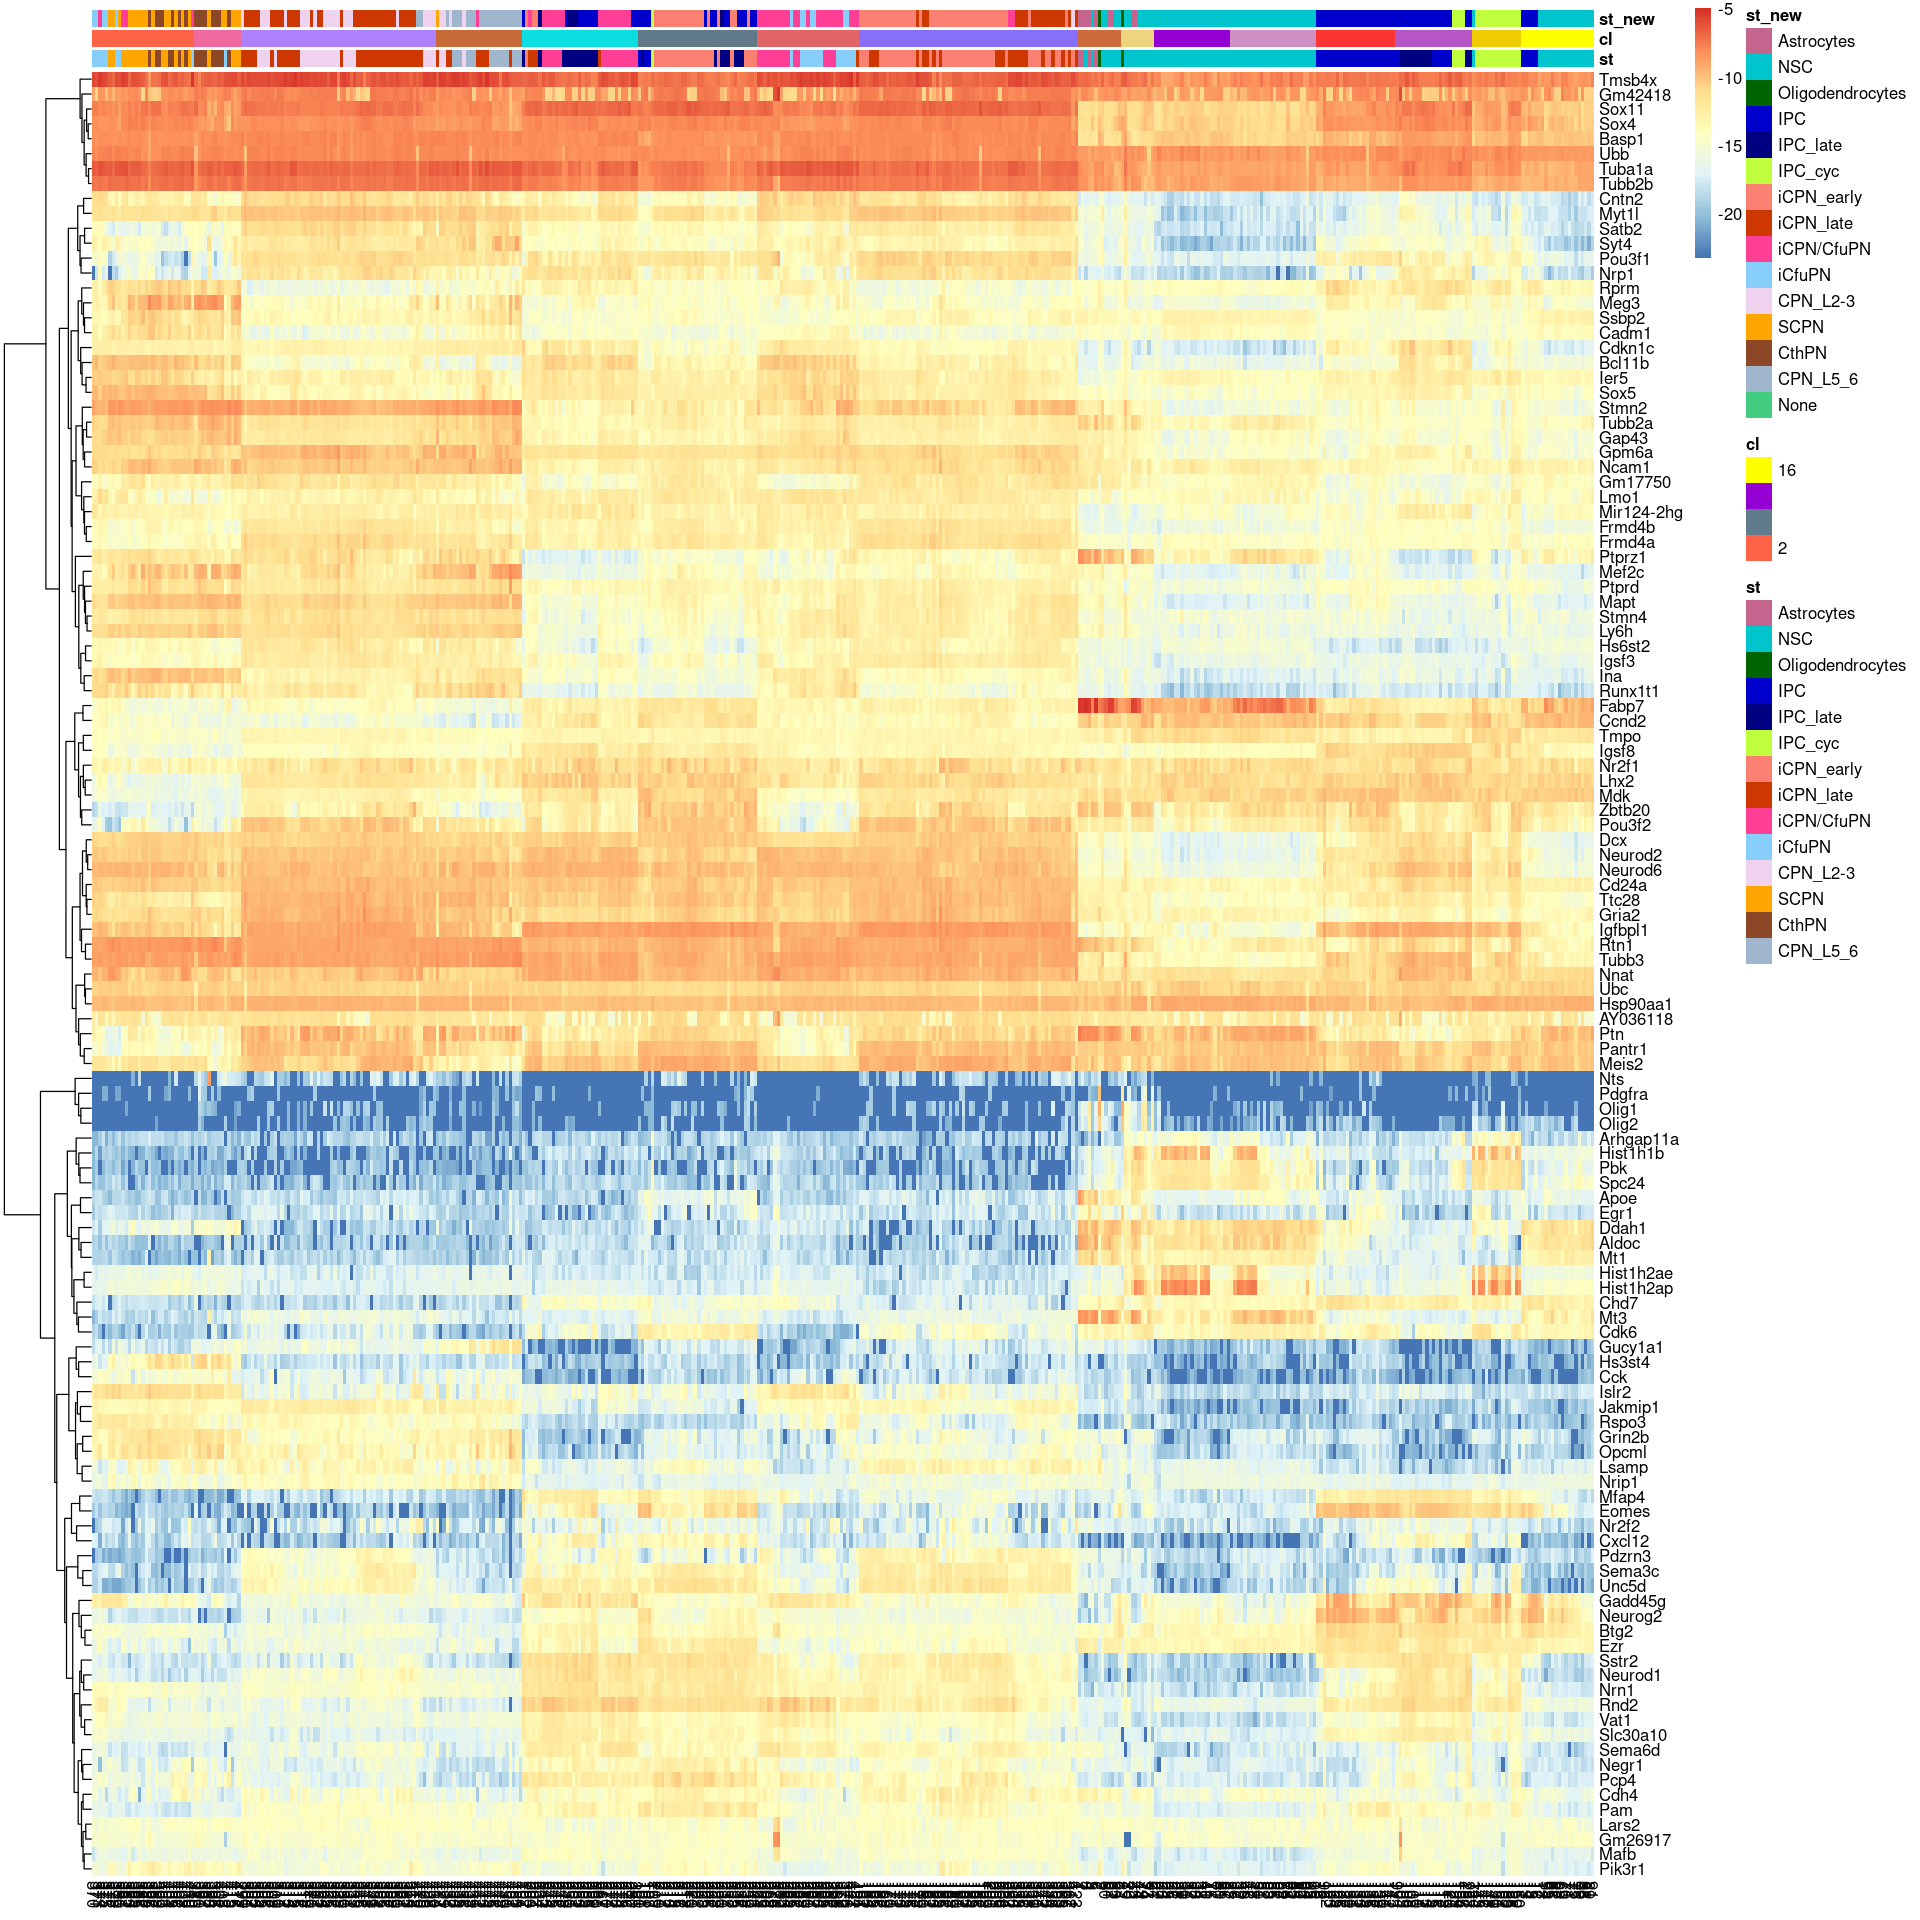

In [45]:
options(repr.plot.width = 16)
options(repr.plot.height = 16)

library(pheatmap)

pheatmap(legc[marks,order(mark_fp_km$cluster)], cluster_cols = F, annotation_col = col_annot, annotation_colors = ann_colors)
options(repr.plot.width = 8)
options(repr.plot.height = 8)

In [33]:
cust_st_ord = c('Oligodendrocytes','Astrocytes','NSC','IPC_cyc', 'IPC','IPC_late', 'iCPN_early','iCPN_late',
                      'CPN_L2-3','CPN_L5_6','iCPN/CfuPN','iCfuPN','SCPN','CthPN')
# cust_mc_ord_st = unlist(lapply(cust_st_ord, function(st) setNames(sort(mcmd$mc[mcmd$st == st]), 
#                                                                   rep(st, length(which(mcmd$st == st))))))
cust_mc_ord_st_new = unlist(lapply(cust_st_ord, function(s) setNames(which(st == s), 
                                                                  rep(s, length(which(st == s)))
                                                                )
                                )
                        )                         

In [34]:
mc2 <- mc

In [35]:
mc2@colors <- color_key$color[match(st, color_key$st)]

In [36]:
scdb_add_mc(id = 'pl_cort_test_colors_reannot', mc2)

In [37]:
mct@mc_id <- "pl_cort_test_colors_reannot"

In [38]:
scdb_add_mctnetwork(id = "pl_cort_test_colors_reannot", mct)

In [39]:
mcf@net_id <- "pl_cort_test_colors_reannot"
scdb_add_mctnetflow("pl_cort_test_colors_reannot", mcf)

In [40]:
mctnetwork_plot_net(mct_id = 'pl_cort_test_colors_reannot', 
                    flow_id = 'pl_cort_test_colors_reannot', 
                    fn = './figs/pl_cort_flow_test_reannot_st_31-8-22.png', 
                    flow_thresh = min(mcf@edge_flows[mcf@edge_flows > 0]), 
                    mc_ord = cust_mc_ord_st_new, plot_mc_ids = F,h = 2000, w = 2000)

png 
  2

In [41]:
mcell_mc2d_plot('pl_cort', colors = ann_colors$st_new[col_annot$st_new], fig_fn = './figs/pl_cort_test_reannot_st_31-8-22.png')

png 
  2

In [62]:
length(cust_mc_ord_st_new)

[1] 454

In [1]:
color_key = vroom::vroom('./data/pl_cort_color_key.tsv')
color_key = color_key %>% tibble::column_to_rownames('st')
color_key$ord = 1:nrow(color_key)
color_key = tibble::rownames_to_column(color_key)
color_key = color_key %>% mutate(i = 1:nrow(color_key)) 
colnames(color_key) = c('cell_type', 'color', 'i', 'ord')
# print(color_key)
readr::write_tsv(color_key, '/net/mraid14/export/tgdata/users/aviezerl/proj/mmcortex/cell_type_annot_YS.tsv')
types_df = data.frame(cbind(1:length(st), st))
colnames(types_df) = c('metacell', 'cell_type')
readr::write_tsv(types_df, '/net/mraid14/export/tgdata/users/aviezerl/proj/mmcortex/types_df.tsv')
mc@colors = color_key$color[match(st, color_key[,'cell_type'])]

In [1]:
print(head(mc@colors))
scdb_add_mc('pl_cort', mc)

mc = scdb_mc('pl_cort')

mct@mc_id = 'pl_cort'
scdb_add_mctnetwork('pl_cort', mct)

mcf@net_id = 'pl_cort'
scdb_add_mctnetflow('pl_cort', mcf)

scdb_init(db_path, force_reinit = T)      

mctnetwork_plot_net(mct_id = 'pl_cort', flow_id = 'pl_cort', fn = './figs/pl_cort_flow.png', flow_thresh = min(mcf@edge_flows[mcf@edge_flows > 0]),  
    colors_ordered = color_key$color[match(cust_st_ord, color_key[,'cell_type'])], plot_mc_ids = F,h = 4000, w = 4000)
mctnetwork_plot_net(mct_id = 'pl_cort', flow_id = 'pl_cort', fn = './figs/pl_cort_flow_mc_id.png', flow_thresh = min(mcf@edge_flows[mcf@edge_flows > 0]),  
    colors_ordered = color_key$color[match(cust_st_ord, color_key[,'cell_type'])], plot_mc_ids = T,h = 4000, w = 4000)

genes_var = rownames(mc@mc_fp)[apply(mc@mc_fp, 1, function(x) length(which(x >= 3)) >= 4 & 
                                     !(st[which.max(x)] %in% c('Astrocytes', 'Oligodendrocytes')))]
# genes_var

lat = scdb_gset('pl_lateral')

length(genes_var[!(genes_var %in% names(lat@gene_set))])
genes_var = genes_var[!(genes_var %in% names(lat@gene_set))]

cor_all = tgs_cor(legc[feats[feats %in% rownames(legc)],], spearman = T)
sl_ord = slanter::slanted_orders(cor_all)
tfs = vroom::vroom('~/raid/Mus_musculus_TF.txt')

tfs = tfs$Symbol
tfs = tfs[tfs %in% rownames(mc@e_gc)]
tfs = tfs[which(apply(mc@mc_fp[tfs,], 1, function(x) max(x) > 3))]

mcell_mc2d_plot('pl_cort')

mcell_mc_plot_marks(mc_id = nm, mc_ord = cust_mc_ord_st, gset_id = 'pl_cort_marks_f', mat_id = nm, 
                    fig_fn = './figs/pl_cort_hm_ord_st_w_km.png', 
                    ext_metadata = setNames(mark_fp_km$cluster[mc@mc], names(mc@mc)))

mcell_mc_plot_marks('pl_cort', gset_id = 'pl_cort_marks_f', mat_id = nm, mc_ord = cust_mc_ord_st, 
                                fig_fn = './figs/pl_cort_hm_by_day.png', add_metadata = 'day')

mcell_mc_plot_marks('pl_cort', gene_list = tfs[order(apply(legc[tfs,sl_ord$rows], 1, which.max))], mat_id = nm, mc_ord = sl_ord$rows, 
                                fig_fn = './figs/pl_cort_hm_tfoi_sl_ord.png',
                   ext_metadata = setNames(mark_fp_km$cluster[mc@mc], names(mc@mc)))

mcell_mc_plot_marks('pl_cort', gene_list = genes_var[order(apply(mc@mc_fp[genes_var,cust_mc_ord_st], 1, function(x) sum(x*1:length(x))/sum(x)))], mat_id = nm, mc_ord = sl_ord$rows, 
                                fig_fn = './figs/pl_cort_hm_genes_var_sl_ord.png',
                   ext_metadata = setNames(mark_fp_km$cluster[mc@mc], names(mc@mc)))


# st_flows = lapply(st_mc_t, function(x) {lapply(seq_along(x), function(mci,n,i) {
#                                p = mc_ag_cn[,n[[i]]];
#                                p = ifelse(1:length(p) == mci[[i]], p, 0); 
#                                mctnetflow_propogate_from_t(mcf = mcf, t = n[[i]], mc_p = p)}, n = x, mci = as.numeric(names(x))
#                                               )
#                                         }
#                   )

# st_flow_mc2 = lapply(st_flows, function(x) {sort(unique(unlist(sapply(x, function(y) apply(y$probs, 2, function(z) which(z > 0))))))})

# st_flow_mc_mat = matrix(0, nrow=length(unique(mc@mc)), ncol = length(neuron_st))
# colnames(st_flow_mc_mat) = neuron_st

# st_flow_mc3 = lapply(seq_along(st_flows), function(x,y,i) {
#                     sort(unique(unlist(sapply(seq_along(x[[i]]), function(j) which(x[[i]][[j]]$probs[,y[[i]][[j]]-1] > 0)))))
#                                                                    }, x=st_flows, y=st_mc_t) 
# names(st_flow_mc3) = neuron_st

# st_flow_mc_mat3 = matrix(0, nrow=length(unique(mc@mc)), ncol = length(neuron_st))
# colnames(st_flow_mc_mat3) = neuron_st

# for (i in 1:length(st_flow_mc2)) {
#     st_flow_mc_mat[st_flow_mc2[[i]],i] = 1
# }

# for (i in 1:length(st_flow_mc3)) {
#     st_flow_mc_mat3[st_flow_mc3[[i]],i] = 1
# }


# icpn_l23_inds = which(st_flow_mc_mat3[,'CPN_L2-3'] > 0 & 
#                       apply(st_flow_mc_mat3[,neuron_st[!(neuron_st == 'CPN_L2-3')]], 1, sum) == 0 & is.na(st))
# st[icpn_l23_inds] = 'iCPN_L2-3'
# icpn_l56_inds = which(st_flow_mc_mat3[,'CPN_L5_6'] > 0 & 
#                       apply(st_flow_mc_mat3[,neuron_st[!(neuron_st == 'CPN_L5_6')]], 1, sum) == 0 & is.na(st))
# st[icpn_l56_inds] = 'iCPN_L5_6'

# icfupn_inds = which(apply(st_flow_mc_mat[,cpn], 1, sum) == 0 & apply(st_flow_mc_mat[,cfupn], 1, sum) > 0 & is.na(st))
# st[icfupn_inds] = 'iCfuPN'

# icpn_inds = which(apply(st_flow_mc_mat[,cpn], 1, sum) > 0 & apply(st_flow_mc_mat[,cfupn], 1, sum) == 0 & is.na(st))
# icpn_inds = icpn_inds[!(icpn_inds %in% union(icpn_l23_inds, icpn_l56_inds))]
# st[icpn_inds] = 'iCPN'


# icpn_cfupn_inds = which(apply(st_flow_mc_mat[,cpn], 1, sum) > 0 & apply(st_flow_mc_mat[,cfupn], 1, sum) > 0 & is.na(st))
# st[icpn_cfupn_inds] = 'iCPN/CfuPN'
                             
# st[is.na(st)] = 'iCPN'


# mcmd_old = vroom::vroom('./BonevCollab//mcmd_cort_6.tsv')
# color_key = unique(mcmd_old[,c('st','color')])
mcmd_new = data.frame(cbind(as.numeric(1:length(st)), st, color_key$color[match(st, color_key[,'cell_type'])]))
colnames(mcmd_new) = c('mc', 'st', 'color')
mcmd_new$color[is.na(mcmd_new$color)] = gplots::col2hex('yellow')

mcmd_new = dplyr::left_join(tibble::rownames_to_column(mcmd_new), 
            tibble::rownames_to_column(data.frame(day_mat)), by='rowname') %>% 
            tibble::column_to_rownames('rowname')

mcmd_new$mean_day = mcmd$mean_day

tb = cut(mcmd_new$mean_day, breaks = seq(13,18,l=14))
mcmd_new$time_bin = match(tb, levels(tb))

head(mcmd_new)
mc@colors = mcmd_new$color
scdb_add_mc('pl_cort', mc)
mcell_mc2d_plot('pl_cort', colors = mcmd_new$color)
mcell_mc2d_plot_by_factor('pl_cort', 'pl_cort', 'day', colors = mcmd_new$color, single_plot = T)

readr::write_tsv(x=mcmd_new, file='./BonevCollab/mcmd_pl_cort.tsv')

ERROR: Error in which(st == s): object 'st' not found
